# HR Attrition Analysis
### Analyzing 1470 employee records to find why employees leave the company
**Tools Used:** Python, Pandas, Matplotlib, Seaborn, SQL
**Dataset:** IBM HR Employee Attrition Dataset

In [1]:
# Importing all required libraries
import pandas as pd               # for data manipulation
import matplotlib.pyplot as plt   # for basic plots
import seaborn as sns             # for beautiful visualizations
import sqlite3                    # for SQL queries
import warnings
warnings.filterwarnings('ignore') # ignore unnecessary warnings

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


In [2]:
# Loading the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 1 — Understanding the Dataset

In [3]:
# Check all column names
print("Columns in dataset:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum().sum(), "missing values found")

Columns in dataset:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
Environm

## Step 2 — Attrition Overview

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


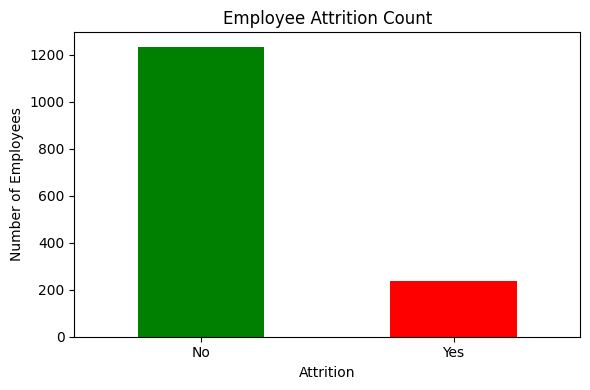

In [4]:
# How many employees left vs stayed
print("Attrition Count:")
print(df['Attrition'].value_counts())
print("\nAttrition Percentage:")
print(df['Attrition'].value_counts(normalize=True)*100)

# Plot
plt.figure(figsize=(6,4))
df['Attrition'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Employee Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 3 — Department wise Attrition

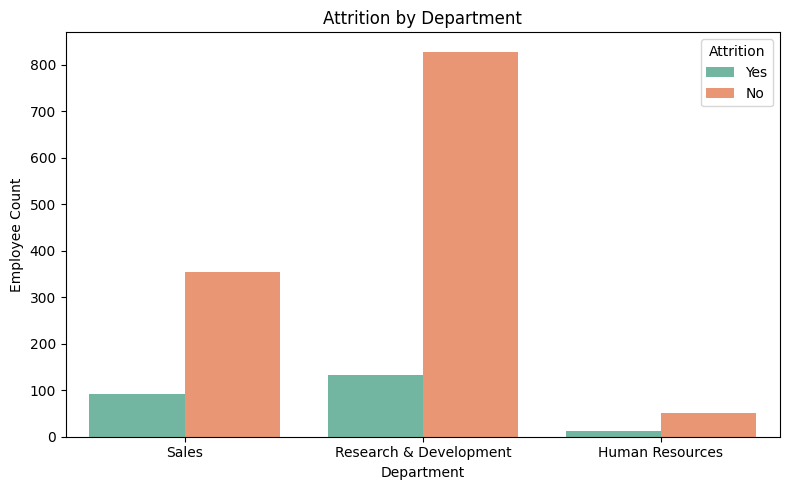

In [5]:
# Which department has most attrition
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set2')
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

## Step 4 — Salary vs Attrition

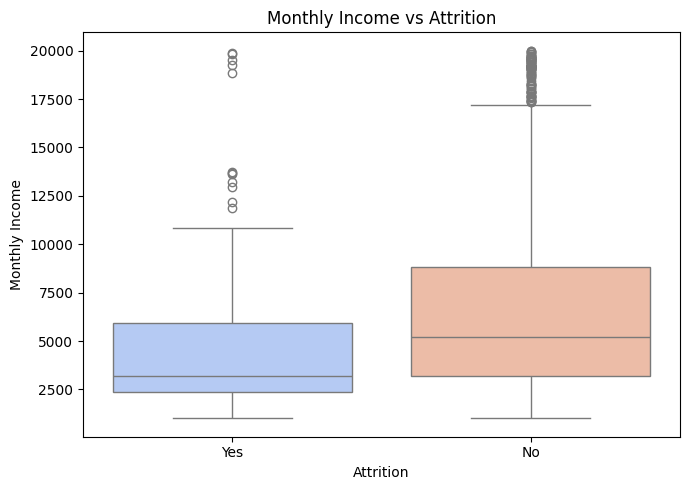

Average salary of employees who LEFT: 4787.09
Average salary of employees who STAYED: 6832.74


In [6]:
# Does salary affect attrition?
plt.figure(figsize=(7,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='coolwarm')
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

# Average salary comparison
print("Average salary of employees who LEFT:", 
      round(df[df['Attrition']=='Yes']['MonthlyIncome'].mean(), 2))
print("Average salary of employees who STAYED:", 
      round(df[df['Attrition']=='No']['MonthlyIncome'].mean(), 2))

## Step 5 — Age vs Attrition

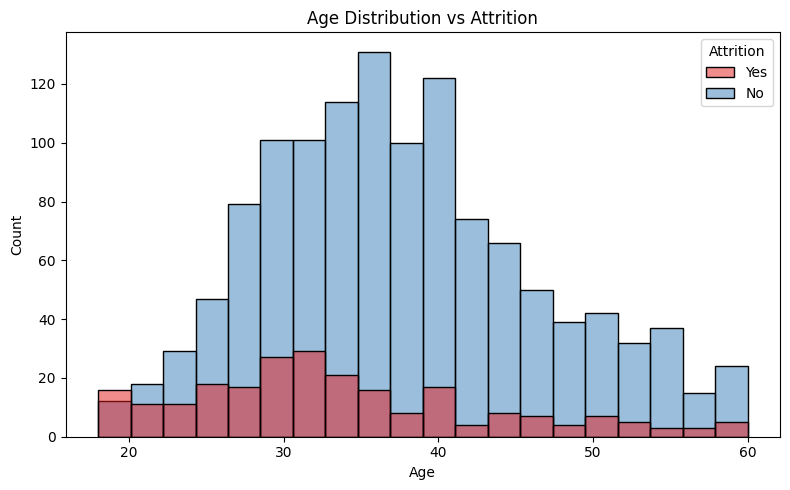

In [7]:
# Which age group leaves most?
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, palette='Set1')
plt.title('Age Distribution vs Attrition')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 6 — Work Life Balance vs Attrition

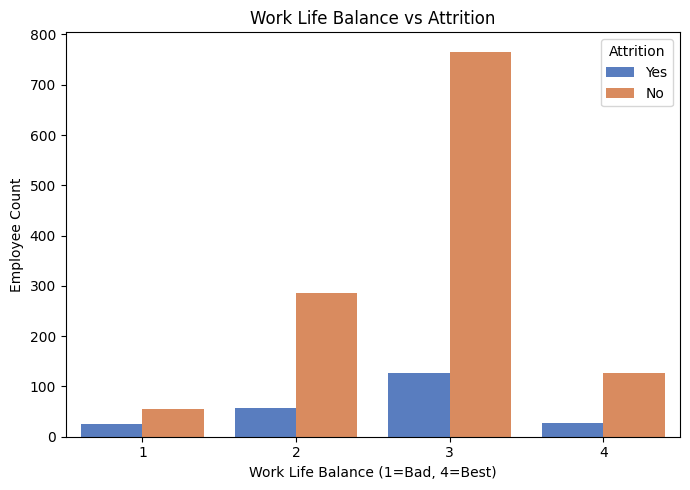

In [8]:
# Work life balance impact
# 1=Bad, 2=Good, 3=Better, 4=Best
plt.figure(figsize=(7,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df, palette='muted')
plt.title('Work Life Balance vs Attrition')
plt.xlabel('Work Life Balance (1=Bad, 4=Best)')
plt.ylabel('Employee Count')
plt.tight_layout()
plt.show()

## Step 7 — SQL Analysis

In [9]:
# Create SQLite database from our dataframe
conn = sqlite3.connect('hr_data.db')
df.to_sql('employees', conn, if_exists='replace', index=False)

# Query 1 — Department wise attrition count
query1 = """
SELECT Department, 
       COUNT(*) as Total_Left
FROM employees
WHERE Attrition = 'Yes'
GROUP BY Department
ORDER BY Total_Left DESC
"""
print("Department wise Attrition:")
print(pd.read_sql(query1, conn))

# Query 2 — Job Role wise attrition
query2 = """
SELECT JobRole,
       COUNT(*) as People_Left,
       ROUND(AVG(MonthlyIncome),2) as Avg_Salary
FROM employees
WHERE Attrition = 'Yes'
GROUP BY JobRole
ORDER BY People_Left DESC
"""
print("\nJob Role wise Attrition:")
print(pd.read_sql(query2, conn))

# Query 3 — Average age of people who left
query3 = """
SELECT Attrition,
       ROUND(AVG(Age),1) as Avg_Age,
       ROUND(AVG(MonthlyIncome),2) as Avg_Income
FROM employees
GROUP BY Attrition
"""
print("\nAverage Age and Income by Attrition:")
print(pd.read_sql(query3, conn))

Department wise Attrition:
               Department  Total_Left
0  Research & Development         133
1                   Sales          92
2         Human Resources          12

Job Role wise Attrition:
                     JobRole  People_Left  Avg_Salary
0      Laboratory Technician           62     2919.26
1            Sales Executive           57     7489.00
2         Research Scientist           47     2780.47
3       Sales Representative           33     2364.73
4            Human Resources           12     3715.75
5     Manufacturing Director           10     7365.50
6  Healthcare Representative            9     8548.22
7                    Manager            5    16797.40
8          Research Director            2    19395.50

Average Age and Income by Attrition:
  Attrition  Avg_Age  Avg_Income
0        No     37.6     6832.74
1       Yes     33.6     4787.09


## Step 8 — Job Role Analysis

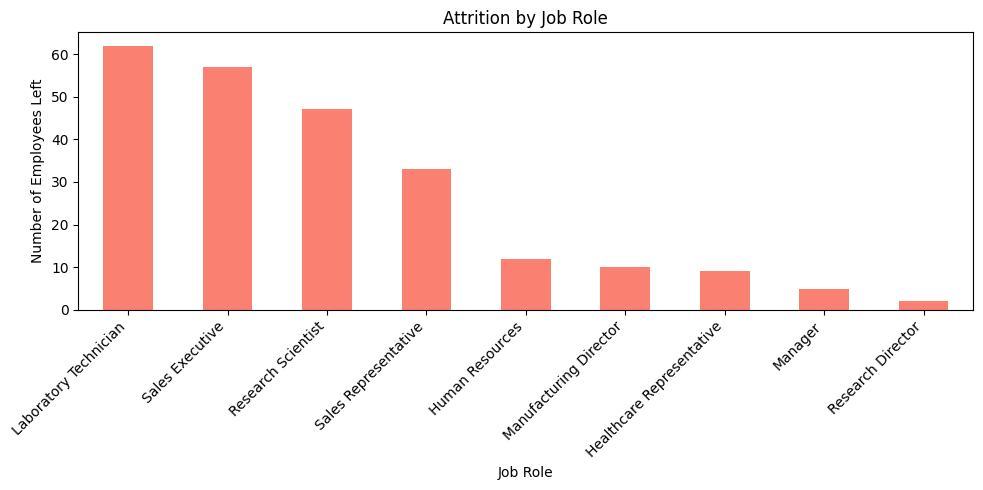

In [10]:
# Which job roles have highest attrition?
job_attrition = df[df['Attrition']=='Yes']['JobRole'].value_counts()

plt.figure(figsize=(10,5))
job_attrition.plot(kind='bar', color='salmon')
plt.title('Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees Left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Key Findings & Business Recommendations

## 📊 Key Findings

1. **Overall Attrition Rate** — 16% of employees left the company
2. **Sales department** has the highest attrition rate
3. **Employees earning less** have significantly higher attrition
4. **Age group 25-35** shows highest tendency to leave
5. **Poor work-life balance** is strongly linked to attrition
6. **Sales Representatives** have highest turnover by job role

## ✅ Business Recommendations

1. Increase salary for roles with high attrition
2. Improve work-life balance policies in Sales department
3. Focus retention efforts on employees aged 25-35
4. Conduct regular feedback sessions for Sales Representatives
5. Introduce performance bonuses to retain low-income employees